(boron-nitride-nb)=
# Boron-nitride ribbon

This boron-nitride ribbon calculation illustrates a case where it is a good idea to change a nonperiodic lattice vector to be
normal to the periodic direction(s).  While the model is physically the same before and after the change, as shown by the
identical band structures, the Berry phase is consistent with the polarization in the extended direction only after the change.

In [1]:
from pythtb import TBModel, WFArray, Mesh, Lattice
import numpy as np
import matplotlib.pyplot as plt

----------------------------------------
       Tight-binding model report       
----------------------------------------
r-space dimension           = 2
k-space dimension           = 2
periodic directions         = [0, 1]
number of orbitals          = 2
number of spin components   = 1
number of electronic states = 2

Lattice vectors (Cartesian):
  # 0 ===> [ 1.000,  0.000]
  # 1 ===> [ 0.500,  0.866]
Volume of unit cell (Cartesian) = 0.866 [A^d]

Reciprocal lattice vectors (Cartesian):
  # 0 ===> [ 6.283, -3.628]
  # 1 ===> [ 0.000,  7.255]
Volume of reciprocal unit cell = 45.586 [A^-d]

Orbital vectors (Cartesian):
  # 0 ===> [ 0.500,  0.289]
  # 1 ===> [ 1.000,  0.577]
Orbital vectors (fractional):
  # 0 ===> [ 0.333,  0.333]
  # 1 ===> [ 0.667,  0.667]
No symmetry operations registered.

----------------------------------------
Site energies:
  # 0 ===> -0.400 
  # 1 ===>  0.400 
Hoppings:
  < 0 | H | 1 + [ 0.0 ,  0.0 ] >  ===> -1.0000
  < 1 | H | 0 + [ 1.0 ,  0.0 ] >  ===> -1.000

(<Figure size 800x800 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

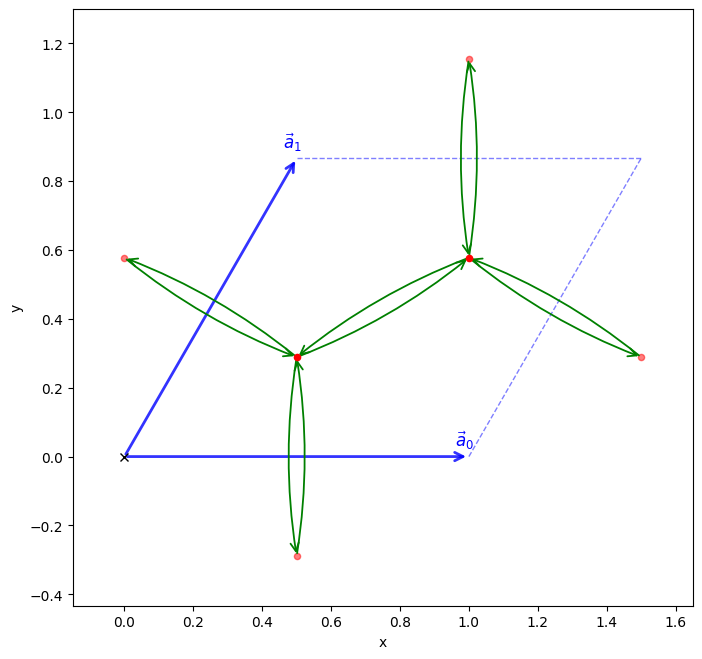

In [2]:
# define lattice vectors
lat_vecs = [[1, 0], [1/2, np.sqrt(3)/2]]
# define coordinates of orbitals
orb_vecs = [[1/3, 1/3], [2/3, 2/3]]

lat = Lattice(lat_vecs, orb_vecs, periodic_dirs=[0, 1])

# make two dimensional tight-binding boron nitride model
my_model = TBModel(lat)

# set periodic model
delta = 0.4
t = -1.0
my_model.set_onsite([-delta, delta])
my_model.set_hop(t, 0, 1, [0, 0])
my_model.set_hop(t, 1, 0, [1, 0])
my_model.set_hop(t, 1, 0, [0, 1])
print(my_model)
my_model.visualize()

## `TBModel.cut_piece`

Now we cut out 3 unit cells along second direction with open boundary conditions to make a ribbon model.

----------------------------------------
       Tight-binding model report       
----------------------------------------
r-space dimension           = 2
k-space dimension           = 1
periodic directions         = [0]
number of orbitals          = 6
number of spin components   = 1
number of electronic states = 6

Lattice vectors (Cartesian):
  # 0 ===> [ 1.000,  0.000]
  # 1 ===> [ 0.500,  0.866]
Volume of unit cell (Cartesian) = 0.866 [A^d]

Reciprocal lattice vectors (Cartesian):
  # 0 ===> [ 6.283,  0.000]
Volume of reciprocal unit cell = 6.283 [A^-d]

Orbital vectors (Cartesian):
  # 0 ===> [ 0.500,  0.289]
  # 1 ===> [ 1.000,  0.577]
  # 2 ===> [ 1.000,  1.155]
  # 3 ===> [ 1.500,  1.443]
  # 4 ===> [ 1.500,  2.021]
  # 5 ===> [ 2.000,  2.309]
Orbital vectors (fractional):
  # 0 ===> [ 0.333,  0.333]
  # 1 ===> [ 0.667,  0.667]
  # 2 ===> [ 0.333,  1.333]
  # 3 ===> [ 0.667,  1.667]
  # 4 ===> [ 0.333,  2.333]
  # 5 ===> [ 0.667,  2.667]
No symmetry operations registered.

----

(<Figure size 800x800 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

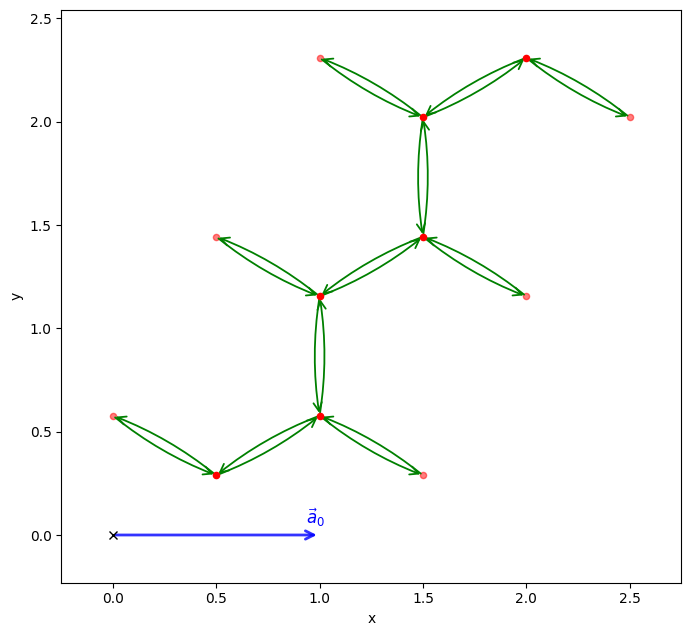

In [3]:
model_orig = my_model.cut_piece(3, 1, glue_edges=False)
print(model_orig)
model_orig.visualize()

## `TBModel.change_nonperiodic_vector`

Construct and display new model with nonperiodic lattice vector changed to be normal to the periodic direction

----------------------------------------
       Tight-binding model report       
----------------------------------------
r-space dimension           = 2
k-space dimension           = 1
periodic directions         = [0]
number of orbitals          = 6
number of spin components   = 1
number of electronic states = 6

Lattice vectors (Cartesian):
  # 0 ===> [ 1.000,  0.000]
  # 1 ===> [ 0.000,  1.000]
Volume of unit cell (Cartesian) = 1.000 [A^d]

Reciprocal lattice vectors (Cartesian):
  # 0 ===> [ 6.283,  0.000]
Volume of reciprocal unit cell = 6.283 [A^-d]

Orbital vectors (Cartesian):
  # 0 ===> [ 0.500,  0.289]
  # 1 ===> [ 1.000,  0.577]
  # 2 ===> [ 1.000,  1.155]
  # 3 ===> [ 1.500,  1.443]
  # 4 ===> [ 1.500,  2.021]
  # 5 ===> [ 2.000,  2.309]
Orbital vectors (fractional):
  # 0 ===> [ 0.500,  0.289]
  # 1 ===> [ 1.000,  0.577]
  # 2 ===> [ 1.000,  1.155]
  # 3 ===> [ 1.500,  1.443]
  # 4 ===> [ 1.500,  2.021]
  # 5 ===> [ 2.000,  2.309]
No symmetry operations registered.

----

(<Figure size 800x800 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

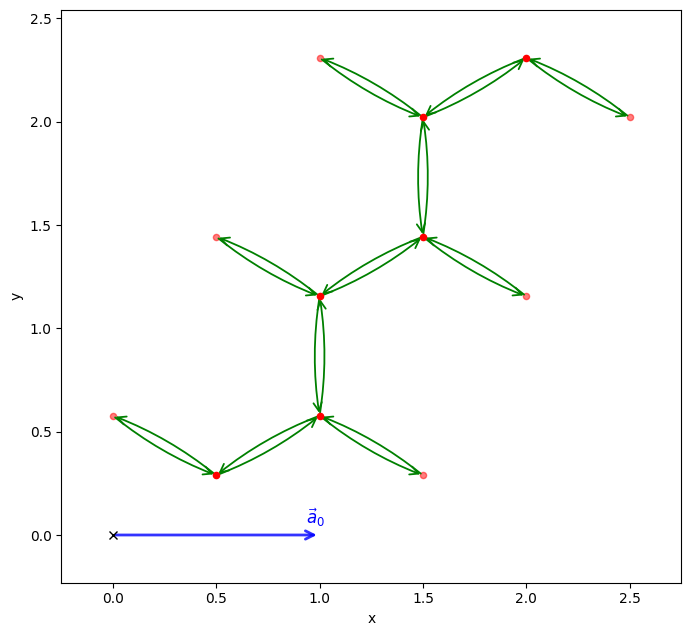

In [5]:
model_perp = model_orig.copy()
model_perp.change_nonperiodic_vector(1, to_home=False)
print(model_perp)
model_perp.visualize()

## Bands and Berry phase
  
Solve both models, showing that the band structures are the same, but Berry phases are different.

We will utilize the `Mesh` to store the k-points, and then solve the model on this mesh using the `WFArray` class and its method
`solve_mesh`.

To compute the Berry phase, we use `WFArray.berry_phase`, passing the band indices and the mesh axis corresponding to direction we compute the Berry phase.

Applying phase to state at beginning to end of open periodic axis.
Appending state at beginning to end of open periodic axis.
Berry Phase Original model = -0.4425504
Applying phase to state at beginning to end of open periodic axis.
Appending state at beginning to end of open periodic axis.
Berry Phase Revised model = -0.0000000


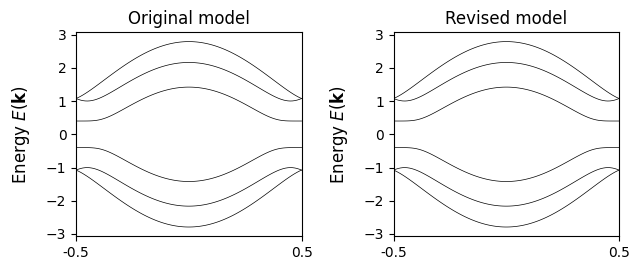

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(6.5, 2.8))

def run_model(model, panel, title):
    k_nodes = [[-0.5], [0.5]]

    model.plot_bands(k_path=k_nodes, nk=100, fig=fig, ax=ax[panel], lc="k", lw=0.5)
    ax[panel].set_title(title)
    ax[panel].set_xticklabels([-0.5, 0.5])

    mesh = Mesh(dim_k=model.dim_k, axis_types=["k"])
    mesh.build_grid(shape=(40,), gamma_centered=True)
    wf = WFArray(model, mesh)
    wf.solve_mesh()

    n_occ = model.nstate // 2
    berry_phase = wf.berry_phase(0, range(n_occ))
    print(f"Berry Phase {title} = {berry_phase:.7f}")

run_model(model_orig, 0, "Original model")
run_model(model_perp, 1, "Revised model")

fig.tight_layout()
plt.show()

## Notes

:::{note}

Let $x$ be along the extended direction and $y$ be normal to it.

This model has an $M_x$ mirror symmetry, so the Berry phase is
expected to be $0$ or $\pi$. We find it to be zero, but only after the
'change_nonperiodic_vector' method is used to force the nonperiodic
"lattice vector" to be perpedicular to the extended direction.

The physical meaning of the Berry phase in the original model
calculation is rather subtle. It is related to the position of
the joint Wannier center (i.e., summed over occupied bands) in
the direction of reciprocal lattice vector 0, which has a
$y$ component as well as an $x$ component (since it must be normal
to real space lattice vector 1). The joint Wannier center gets
displaced along $y$ as the hopping $t$ is changed, so the Berry
phase calculation gets "contaminated" by this displacement.

Another way to see this is to note that the Wilson loop operator
involves a product of overlaps of states at $k$ and $k+\Delta k$,
where $\Delta k$ is along reciprocal lattice vector 0. Since this
vector has a $y$ component, the Wilson loop operator involves
phase factors $e^{i k \cdot r}$ that depend on both $x$ and $y$ positions of the orbitals. Thus, the Berry phase
calculation is sensitive to displacements of Wannier centers in $y$ as well as in $x$. In the oblique cell, the reciprocal loop vector $\mathbf{b_1}$ has a y-component. This means the Wilson loop closure multiplies states by phases depending on both x and y orbital positions. As a result, the Berry phase along the “periodic x” direction is contaminated by shifts of Wannier centers in y. Orthogonalizing the non-periodic lattice vector removes this mixing: now $\mathbf{b_1}$ points purely along x, so the Berry phase tracks only polarization along x. With mirror symmetry, this is forced to vanish, and indeed the Berry phase comes out zero. The band structure is unaffected because it depends only on x-periodicity, not on the definition of the non-periodic cell vector.
:::